# 3DSRP — Benchmark

Cinq expériences indépendantes :

| Exp | Varied | Fixed | Objectif |
|-----|--------|-------|----------|
| 0   | `c` (génération ASP) | n=4, m=2, k=2, w=2 | Vitesse du générateur ASP (`generator.lp`) |
| 1   | `c` (taille plateau) | n=6, m=3, k=3, w=4 | Standard vs Filomino |
| 2   | `m` × `k` (heatmap)  | c=60, n=6, w=0      | Standard vs Filomino |
| 3   | `w` (murs)           | c=80, n=6, m=4, k=3 | Standard vs Filomino |
| 4   | `h` (indices)        | c=80, n=6, m=4, k=3, w=10 | Filomino progressif |

> **Standard** = solveur 5-règles sans indices de taille.  
> **Filomino** = même solveur + `cell_size_hint` (H_MAX indices par instance).  
> Génération Exp 1-4 : générateur constructif Python (< 2 ms). Exp 0 : générateur ASP Clingo.  
> Métrique : **PAR-2** (timeout → 2 × TIMEOUT dans la moyenne).  
> Pour Exp 1-3 : Standard et Filomino résolvent **la même instance** (générée une fois avec `filomino=1`).

In [1]:
from __future__ import annotations
import csv, sys, time
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# benchmark/ (constructive_generator.py) + KRR_project/ (main.py)
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))
import main as solver

RESULTS = Path('results')
RESULTS.mkdir(exist_ok=True)

TIMEOUT    = 60      # solver timeout per run (seconds)
N_RUNS     = 20      # repetitions per configuration
H_MAX      = 8       # max Filomino hints generated per instance (Exp 4)
USE_CLINGO = False   # False = fast constructive Python generator (Exp 1-4)

print(f'Ready — TIMEOUT={TIMEOUT}s  N_RUNS={N_RUNS}  H_MAX={H_MAX}  USE_CLINGO={USE_CLINGO}')

Ready — TIMEOUT=60s  N_RUNS=20  H_MAX=8  USE_CLINGO=False


In [2]:
# ── CSV helpers ─────────────────────────────────────────────────────────────

def init_csv(path):
    with path.open('w', newline='') as f:
        csv.writer(f).writerow([
            'variant', 'varied_param', 'value',
            'c', 'n', 'm', 'k', 'w', 'h', 'run',
            't_gen_ms', 'seconds', 'timeout'
        ])

def append_row(path, *, variant, varied_param, value,
               c, n, m, k, w, h=0, run, t_gen_ms=0, seconds):
    to = (seconds == float('inf'))
    with path.open('a', newline='') as f:
        csv.writer(f).writerow([
            variant, varied_param, value,
            c, n, m, k, w, h, run,
            f'{t_gen_ms:.2f}',
            '' if to else f'{seconds:.5f}',
            int(to)
        ])

def aggregate(csv_path, par=2):
    """PAR-n aggregation. Timeouts count as par * TIMEOUT."""
    df = pd.read_csv(csv_path)
    df['seconds'] = pd.to_numeric(df['seconds'], errors='coerce')
    df['score'] = df.apply(
        lambda r: r['seconds'] if r['timeout'] == 0 else par * TIMEOUT, axis=1
    )
    agg = (df.groupby(['variant', 'value'])['score']
             .agg(score='mean', std='std')
             .reset_index()
             .sort_values(['variant', 'value']))
    n_to = (df[df['timeout'] == 1]
              .groupby(['variant', 'value']).size()
              .reset_index(name='n_timeouts'))
    return agg.merge(n_to, on=['variant', 'value'], how='left').fillna({'n_timeouts': 0})

# ── Plotting ─────────────────────────────────────────────────────────────────

STYLES = {
    'standard': ('o-',  '#2980B9', 'Standard'),
    'filomino': ('s--', '#E74C3C', f'Filomino ({H_MAX} hints)'),
}

def plot_line(agg_df, xlabel, title, out_svg=None):
    fig, ax = plt.subplots(figsize=(7, 4))
    ymax = agg_df['score'].max() * 1000 * 1.08
    for variant, (fmt, color, label) in STYLES.items():
        sub = agg_df[agg_df['variant'] == variant].sort_values('value')
        if sub.empty:
            continue
        ax.plot(sub['value'], sub['score'] * 1000, fmt, color=color,
                linewidth=2, label=label)
        to = sub[sub['n_timeouts'] > 0]
        if not to.empty:
            ax.scatter(to['value'], [ymax] * len(to),
                       marker='x', s=80, color=color, zorder=5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('PAR-2 score (ms)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle=':', linewidth=0.5)
    fig.tight_layout()
    if out_svg:
        fig.savefig(out_svg, format='svg')
        print(f'Saved {out_svg}')
    plt.show()

# ── Instance generation ──────────────────────────────────────────────────────

def generate_instances(configs, h=H_MAX, n_runs=N_RUNS):
    """Generate all puzzle instances once. Returns dict (ci, run) -> facts list."""
    instances = {}
    total = len(configs) * n_runs
    cur = 0
    for ci, (val, c, n, m, k, w) in enumerate(configs):
        for run in range(n_runs):
            cur += 1
            if cur % 20 == 1 or cur == total:
                print(f'  [{cur}/{total}] gen  {val}  run={run+1}')
            ok = solver.run_generator(c, n, m, k, w, filomino=1, h=h,
                                      use_clingo=USE_CLINGO)
            instances[(ci, run)] = list(solver.facts) if ok else None
    n_ok = sum(1 for v in instances.values() if v is not None)
    print(f'  Generated {n_ok}/{total} instances successfully.')
    return instances

# ── Solving ──────────────────────────────────────────────────────────────────

def solve_variant(instances, configs, csv_path, varied_param,
                  variant, use_hints, h_limit=None, n_runs=N_RUNS):
    """Solve all instances for one variant. Writes its own CSV."""
    init_csv(csv_path)
    total = len(configs) * n_runs
    cur = 0
    n_timeouts = 0
    for ci, (val, c, n, m, k, w) in enumerate(configs):
        for run in range(n_runs):
            cur += 1
            inst = instances.get((ci, run))
            if inst is None:
                append_row(csv_path, variant=variant, varied_param=varied_param,
                           value=val, c=c, n=n, m=m, k=k, w=w,
                           h=h_limit or 0, run=run+1, seconds=float('inf'))
                n_timeouts += 1
                continue
            solver.facts = list(inst)
            secs = solver.run_solver(use_hints=use_hints, h_limit=h_limit,
                                     timeout=TIMEOUT)
            append_row(csv_path, variant=variant, varied_param=varied_param,
                       value=val, c=c, n=n, m=m, k=k, w=w,
                       h=h_limit or 0, run=run+1, seconds=secs)
            if secs == float('inf'):
                n_timeouts += 1
            if cur % 20 == 0 or cur == total:
                print(f'  [{cur}/{total}] {variant}  {varied_param}={val}')
    print(f'  Done. {n_timeouts} timeouts / {total} runs.')

print('Helpers ready.')

Helpers ready.


## Warmup — Générateur constructif Python
Validation que la génération constructive est quasi-instantanée sur toute la plage de c.

In [4]:
print(f'{'c':>4}  {'mean (ms)':>10}  {'max (ms)':>9}')
for c in [8, 16, 24, 32, 40, 48, 56, 64, 80, 100, 120]:
    n = int(c**(1/3)) + 2
    times = []
    for _ in range(30):
        t0 = time.perf_counter()
        solver.run_generator(c, n, 2, 2, 2, use_clingo=False)
        times.append((time.perf_counter() - t0) * 1000)
    print(f'{c:4d}  {sum(times)/len(times):10.2f}  {max(times):9.1f}')

   c   mean (ms)   max (ms)
   8        0.07        0.1
  16        0.16        0.2
  24        0.26        0.4
  32        0.30        0.5
  40        0.35        0.7
  48        0.36        0.6
  56        0.40        0.7
  64        0.51        0.8
  80        0.64        1.2
 100        0.74        0.9
 120        0.87        1.4


## Expérience 0 — Vitesse du générateur ASP (`generator.lp`)
Mesure le temps de génération Clingo en fonction de `c`.  
Fixé : n=4, m=2, k=2, w=2 — timeout=30 s par run.  
Plus `c` est grand, plus la recherche ASP est difficile (espace de recherche exponentiel).

In [9]:
import csv
import time
from pathlib import Path

ASP_TIMEOUT = 30
N_RUNS_GEN = 3

# ── CONFIG FIXE ─────────────────────────────
N_VALS = [7]
M_GEN, K_GEN, W_GEN = 4, 3, 5

# ── échantillonnage plus précis ─────────────
C_RATIOS = [
    0.08, 0.10, 0.12, 0.14, 0.16, 0.18,
    0.20, 0.25, 0.30, 0.35, 0.40
]

C_MIN = max(M_GEN * 4, M_GEN * K_GEN)

CSV_GEN = RESULTS / "exp_gen_asp.csv"

with CSV_GEN.open("w", newline="") as f:
    csv.writer(f).writerow([
        "n", "ratio", "c", "m", "k", "w", "run", "t_gen_ms", "timeout"
    ])

configs = []

# ── génération des configs ───────────────────────────────
for n in N_VALS:
    max_c = n ** 3

    for r in C_RATIOS:
        c = int(r * max_c)

        # respect contrainte minimale
        if c < C_MIN:
            continue

        configs.append((n, r, c))

total = len(configs) * N_RUNS_GEN
cur = 0

print(f"{len(configs)} configs valides")

# ── exécution ────────────────────────────────────────────
for n, r, c in configs:
    for run in range(1, N_RUNS_GEN + 1):
        cur += 1

        print(f"[{cur}/{total}] n={n} c={c} ({r:.2f}) run={run}")

        t0 = time.perf_counter()

        ok = solver.run_generator(
            c,
            n,
            M_GEN,
            K_GEN,
            W_GEN,
            use_clingo=True,
            timeout=ASP_TIMEOUT
        )

        t_ms = (time.perf_counter() - t0) * 1000

        with CSV_GEN.open("a", newline="") as f:
            csv.writer(f).writerow([
                n,
                f"{r:.2f}",
                c,
                M_GEN,
                K_GEN,
                W_GEN,
                run,
                f"{t_ms:.1f}",
                int(not ok)
            ])

        if not ok:
            print(f"  -> timeout (n={n}, c={c})")

print("Done.")

11 configs valides
[1/33] n=7 c=27 (0.08) run=1
[2/33] n=7 c=27 (0.08) run=2
[3/33] n=7 c=27 (0.08) run=3
[4/33] n=7 c=34 (0.10) run=1
[5/33] n=7 c=34 (0.10) run=2
[6/33] n=7 c=34 (0.10) run=3
[7/33] n=7 c=41 (0.12) run=1
[8/33] n=7 c=41 (0.12) run=2
[9/33] n=7 c=41 (0.12) run=3
[10/33] n=7 c=48 (0.14) run=1
[11/33] n=7 c=48 (0.14) run=2
[12/33] n=7 c=48 (0.14) run=3
[13/33] n=7 c=54 (0.16) run=1
[14/33] n=7 c=54 (0.16) run=2
[15/33] n=7 c=54 (0.16) run=3
[16/33] n=7 c=61 (0.18) run=1
[17/33] n=7 c=61 (0.18) run=2
[18/33] n=7 c=61 (0.18) run=3
  -> timeout (n=7, c=61)
[19/33] n=7 c=68 (0.20) run=1
[20/33] n=7 c=68 (0.20) run=2
[21/33] n=7 c=68 (0.20) run=3
[22/33] n=7 c=85 (0.25) run=1
[23/33] n=7 c=85 (0.25) run=2
[24/33] n=7 c=85 (0.25) run=3
[25/33] n=7 c=102 (0.30) run=1
[26/33] n=7 c=102 (0.30) run=2
[27/33] n=7 c=102 (0.30) run=3
[28/33] n=7 c=120 (0.35) run=1
[29/33] n=7 c=120 (0.35) run=2
[30/33] n=7 c=120 (0.35) run=3
[31/33] n=7 c=137 (0.40) run=1
[32/33] n=7 c=137 (0.40) run

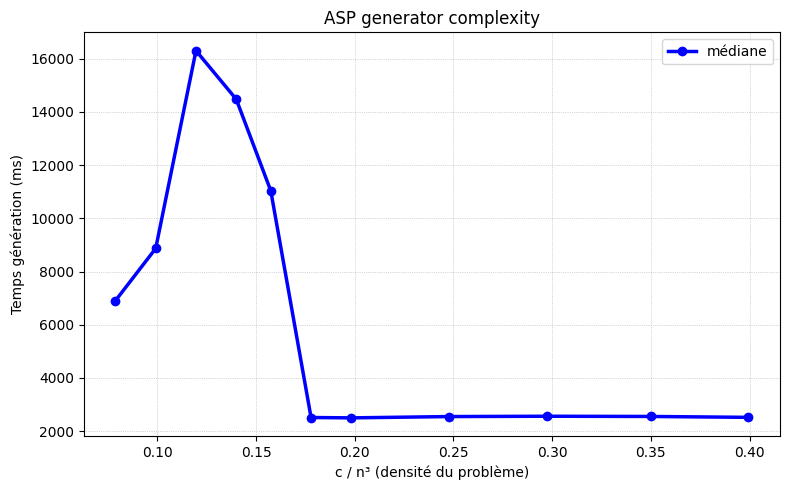

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(CSV_GEN)

df['t_gen_ms'] = pd.to_numeric(df['t_gen_ms'], errors='coerce')

# enlever timeout
df = df[df['timeout'] == 0]

df['ratio'] = df['c'] / (df['n'] ** 3)

# ── agrégation ROBUSTE ───────────────
agg = (
    df.groupby('ratio')['t_gen_ms']
    .agg(
        median='median',
        mean='mean',
        std='std'
    )
    .reset_index()
    .sort_values('ratio')
)

# smoothing médiane
agg['smooth'] = agg['median'].rolling(3, center=True, min_periods=1).mean()

# ── plot ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    agg['ratio'],
    agg['smooth'],
    'o-',
    color='blue',
    linewidth=2.5,
    label='médiane'
)

# ── style ───────────────────────────
ax.set_xlabel('c / n³ (densité du problème)')
ax.set_ylabel('Temps génération (ms)')
ax.set_title('ASP generator complexity')

ax.grid(True, linestyle=':', linewidth=0.5)
ax.legend()

plt.tight_layout()
plt.show()

## Expérience 1 — Effet de `c` (taille du plateau)
Fixé : n=6, m=3, k=3, w=4.  
Les instances sont générées **une seule fois** avec Filomino (H_MAX indices), puis résolues
séparément en mode Standard et Filomino — garantissant qu'on teste le même puzzle.

In [6]:
configs_c = [
    (c, c, 6, 3, 3, 4)
    for c in [40, 50, 60, 70, 80, 90, 100, 110, 120]
]
print(f'Exp 1 : {len(configs_c)} configs x {N_RUNS} runs = {len(configs_c)*N_RUNS} instances')
instances_c = generate_instances(configs_c, h=H_MAX, n_runs=N_RUNS)

Exp 1 : 9 configs x 20 runs = 180 instances
  [1/180] gen  40  run=1
  [21/180] gen  50  run=1
  [41/180] gen  60  run=1
  [61/180] gen  70  run=1
  [81/180] gen  80  run=1
  [101/180] gen  90  run=1
  [121/180] gen  100  run=1
  [141/180] gen  110  run=1
  [161/180] gen  120  run=1
  [180/180] gen  120  run=20
  Generated 180/180 instances successfully.


In [7]:
CSV_C_STD = RESULTS / 'exp_c_standard.csv'
print('=== Exp 1 — Standard ===')
solve_variant(instances_c, configs_c, CSV_C_STD, 'c',
              variant='standard', use_hints=False, n_runs=N_RUNS)

=== Exp 1 — Standard ===
  [20/180] standard  c=40
  [40/180] standard  c=50
  [60/180] standard  c=60
  [80/180] standard  c=70
  [100/180] standard  c=80
  [120/180] standard  c=90
  [140/180] standard  c=100
  [160/180] standard  c=110
  [180/180] standard  c=120
  Done. 1 timeouts / 180 runs.


In [9]:
CSV_C_FIL = RESULTS / 'exp_c_filomino.csv'
print(f'=== Exp 1 — Filomino ({H_MAX} hints) ===')
solve_variant(instances_c, configs_c, CSV_C_FIL, 'c',
              variant='filomino', use_hints=True, h_limit=H_MAX, n_runs=N_RUNS)

=== Exp 1 — Filomino (8 hints) ===
  [20/180] filomino  c=40
  [40/180] filomino  c=50
  [60/180] filomino  c=60
  [80/180] filomino  c=70
  [100/180] filomino  c=80
  [120/180] filomino  c=90
  [140/180] filomino  c=100
  [160/180] filomino  c=110
  [180/180] filomino  c=120
  Done. 1 timeouts / 180 runs.


 variant  value    score       std  n_timeouts
filomino     40 0.003442  0.000890         0.0
filomino     50 0.008726  0.007360         0.0
filomino     60 0.014094  0.015589         0.0
filomino     70 0.066071  0.145891         0.0
filomino     80 0.270536  0.446029         0.0
filomino     90 7.182347 26.637522         1.0
filomino    100 1.820410  4.477324         0.0
filomino    110 2.115826  2.321984         0.0
filomino    120 2.670037  3.782230         0.0
standard     40 0.003576  0.001500         0.0
standard     50 0.007457  0.005498         0.0
standard     60 0.011622  0.007535         0.0
standard     70 0.901073  3.653293         0.0
standard     80 2.880603  4.144128         0.0
standard     90 6.979725 26.634470         1.0
standard    100 6.993825 16.869319         0.0
standard    110 3.095934  8.517322         0.0
standard    120 2.630018  2.439102         0.0
Saved results\exp_c.svg


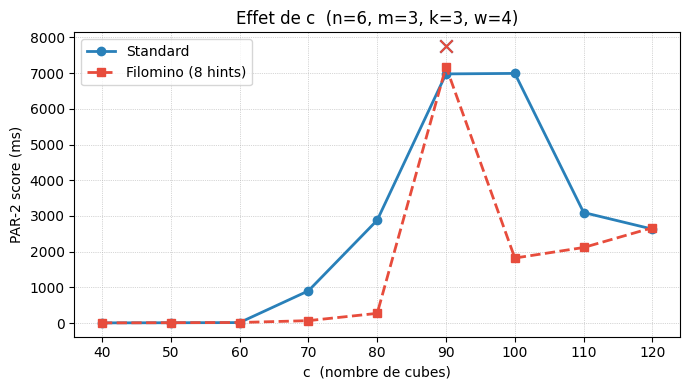

In [28]:
df_c = pd.concat([pd.read_csv(CSV_C_STD), pd.read_csv(CSV_C_FIL)], ignore_index=True)
df_c['seconds'] = pd.to_numeric(df_c['seconds'], errors='coerce')
df_c['score'] = df_c.apply(lambda r: r['seconds'] if r['timeout']==0 else 2*TIMEOUT, axis=1)

agg_c = (df_c.groupby(['variant', 'value'])['score']
          .agg(score='mean', std='std').reset_index().sort_values(['variant', 'value']))
n_to_c = (df_c[df_c['timeout']==1]
           .groupby(['variant','value']).size().reset_index(name='n_timeouts'))
agg_c = agg_c.merge(n_to_c, on=['variant','value'], how='left').fillna({'n_timeouts': 0})

print(agg_c.to_string(index=False))
plot_line(agg_c,
    xlabel='c  (nombre de cubes)',
    title='Effet de c  (n=6, m=3, k=3, w=4)',
    out_svg=RESULTS / 'exp_c.svg')

## Expérience 2 — Effet de `m` × `k` (heatmap)
Fixé : c=60, n=6, w=0.  
Les cases **noires** correspondent aux combinaisons impossibles (c < m × max(4, k)).

In [11]:
C_MK   = 60
M_VALS = list(range(2, C_MK // 4 + 1))   # 2..15
K_VALS = list(range(1, C_MK // 4 + 1))   # 1..15

configs_mk = [
    (f'm{m}k{k}', C_MK, 6, m, k, 0)
    for m in M_VALS for k in K_VALS
    if C_MK >= m * max(4, k)
]
n_impossible = len(M_VALS) * len(K_VALS) - len(configs_mk)
print(f'Valides: {len(configs_mk)}  Impossibles (noir): {n_impossible}')
print(f'Total runs: {len(configs_mk) * N_RUNS}')
instances_mk = generate_instances(configs_mk, h=H_MAX, n_runs=N_RUNS)

Valides: 116  Impossibles (noir): 94
Total runs: 2320
  [1/2320] gen  m2k1  run=1
  [21/2320] gen  m2k2  run=1
  [41/2320] gen  m2k3  run=1
  [61/2320] gen  m2k4  run=1
  [81/2320] gen  m2k5  run=1
  [101/2320] gen  m2k6  run=1
  [121/2320] gen  m2k7  run=1
  [141/2320] gen  m2k8  run=1
  [161/2320] gen  m2k9  run=1
  [181/2320] gen  m2k10  run=1
  [201/2320] gen  m2k11  run=1
  [221/2320] gen  m2k12  run=1
  [241/2320] gen  m2k13  run=1
  [261/2320] gen  m2k14  run=1
  [281/2320] gen  m2k15  run=1
  [301/2320] gen  m3k1  run=1
  [321/2320] gen  m3k2  run=1
  [341/2320] gen  m3k3  run=1
  [361/2320] gen  m3k4  run=1
  [381/2320] gen  m3k5  run=1
  [401/2320] gen  m3k6  run=1
  [421/2320] gen  m3k7  run=1
  [441/2320] gen  m3k8  run=1
  [461/2320] gen  m3k9  run=1
  [481/2320] gen  m3k10  run=1
  [501/2320] gen  m3k11  run=1
  [521/2320] gen  m3k12  run=1
  [541/2320] gen  m3k13  run=1
  [561/2320] gen  m3k14  run=1
  [581/2320] gen  m3k15  run=1
  [601/2320] gen  m4k1  run=1
  [621/232

In [12]:
CSV_MK_STD = RESULTS / 'exp_mk_standard.csv'
print('=== Exp 2 — Standard ===')
solve_variant(instances_mk, configs_mk, CSV_MK_STD, 'mk',
              variant='standard', use_hints=False, n_runs=N_RUNS)

=== Exp 2 — Standard ===
  [20/2320] standard  mk=m2k1
  [40/2320] standard  mk=m2k2
  [60/2320] standard  mk=m2k3
  [80/2320] standard  mk=m2k4
  [100/2320] standard  mk=m2k5
  [120/2320] standard  mk=m2k6
  [140/2320] standard  mk=m2k7
  [160/2320] standard  mk=m2k8
  [180/2320] standard  mk=m2k9
  [200/2320] standard  mk=m2k10
  [220/2320] standard  mk=m2k11
  [240/2320] standard  mk=m2k12
  [260/2320] standard  mk=m2k13
  [280/2320] standard  mk=m2k14
  [300/2320] standard  mk=m2k15
  [320/2320] standard  mk=m3k1
  [340/2320] standard  mk=m3k2
  [360/2320] standard  mk=m3k3
  [380/2320] standard  mk=m3k4
  [400/2320] standard  mk=m3k5
  [420/2320] standard  mk=m3k6
  [440/2320] standard  mk=m3k7
  [460/2320] standard  mk=m3k8
  [480/2320] standard  mk=m3k9
  [500/2320] standard  mk=m3k10
  [520/2320] standard  mk=m3k11
  [540/2320] standard  mk=m3k12
  [560/2320] standard  mk=m3k13
  [580/2320] standard  mk=m3k14
  [600/2320] standard  mk=m3k15
  [620/2320] standard  mk=m4k1
  [640

In [13]:
CSV_MK_FIL = RESULTS / 'exp_mk_filomino.csv'
print(f'=== Exp 2 — Filomino ({H_MAX} hints) ===')
solve_variant(instances_mk, configs_mk, CSV_MK_FIL, 'mk',
              variant='filomino', use_hints=True, h_limit=H_MAX, n_runs=N_RUNS)

=== Exp 2 — Filomino (8 hints) ===
  [20/2320] filomino  mk=m2k1
  [40/2320] filomino  mk=m2k2
  [60/2320] filomino  mk=m2k3
  [80/2320] filomino  mk=m2k4
  [100/2320] filomino  mk=m2k5
  [120/2320] filomino  mk=m2k6
  [140/2320] filomino  mk=m2k7
  [160/2320] filomino  mk=m2k8
  [180/2320] filomino  mk=m2k9
  [200/2320] filomino  mk=m2k10
  [220/2320] filomino  mk=m2k11
  [240/2320] filomino  mk=m2k12
  [260/2320] filomino  mk=m2k13
  [280/2320] filomino  mk=m2k14
  [300/2320] filomino  mk=m2k15
  [320/2320] filomino  mk=m3k1
  [340/2320] filomino  mk=m3k2
  [360/2320] filomino  mk=m3k3
  [380/2320] filomino  mk=m3k4
  [400/2320] filomino  mk=m3k5
  [420/2320] filomino  mk=m3k6
  [440/2320] filomino  mk=m3k7
  [460/2320] filomino  mk=m3k8
  [480/2320] filomino  mk=m3k9
  [500/2320] filomino  mk=m3k10
  [520/2320] filomino  mk=m3k11
  [540/2320] filomino  mk=m3k12
  [560/2320] filomino  mk=m3k13
  [580/2320] filomino  mk=m3k14
  [600/2320] filomino  mk=m3k15
  [620/2320] filomino  mk=m

Saved results\exp_mk.svg


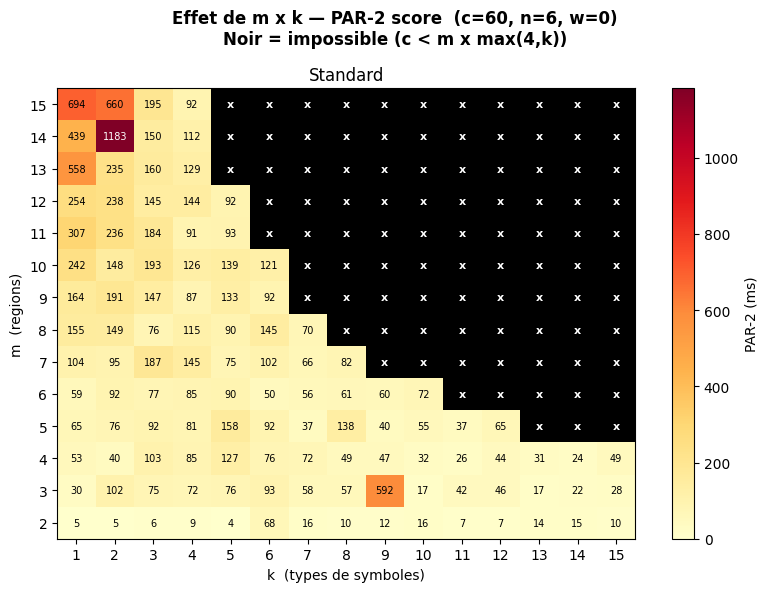

In [20]:
def mk_pivot(csv_path):
    df = pd.read_csv(csv_path)
    df['seconds'] = pd.to_numeric(df['seconds'], errors='coerce')
    df['score'] = df.apply(
        lambda r: r['seconds'] if r['timeout']==0 else 2*TIMEOUT, axis=1
    )
    return (
        df.groupby(['m','k'])['score'].mean()
          .reindex(pd.MultiIndex.from_product([M_VALS, K_VALS], names=['m','k']))
          .unstack('k') * 1000
    )

pivot_std = mk_pivot(CSV_MK_STD)

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad('black')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle(
    f'Effet de m x k — PAR-2 score  (c={C_MK}, n=6, w=0)\nNoir = impossible (c < m x max(4,k))',
    fontsize=12, fontweight='bold'
)

masked = np.ma.masked_invalid(pivot_std.values)
vmax = float(masked.max()) if masked.count() > 0 else 1.0

im = ax.imshow(masked, aspect='auto', cmap=cmap, origin='lower',
               vmin=0, vmax=vmax)

ax.set_xticks(range(len(K_VALS)))
ax.set_xticklabels(K_VALS)
ax.set_yticks(range(len(M_VALS)))
ax.set_yticklabels(M_VALS)
ax.set_xlabel('k  (types de symboles)')
ax.set_ylabel('m  (regions)')
ax.set_title('Standard')

for i, m in enumerate(M_VALS):
    for j, k in enumerate(K_VALS):
        try:
            val = pivot_std.loc[m, k]
        except KeyError:
            val = float('nan')
        if np.isnan(val):
            ax.text(j, i, 'x', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
        else:
            color = 'white' if val > vmax * 0.65 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='PAR-2 (ms)')

fig.tight_layout()
fig.savefig(RESULTS / 'exp_mk.svg', format='svg')
print('Saved', RESULTS / 'exp_mk.svg')
plt.show()

Saved results\exp_mk.svg


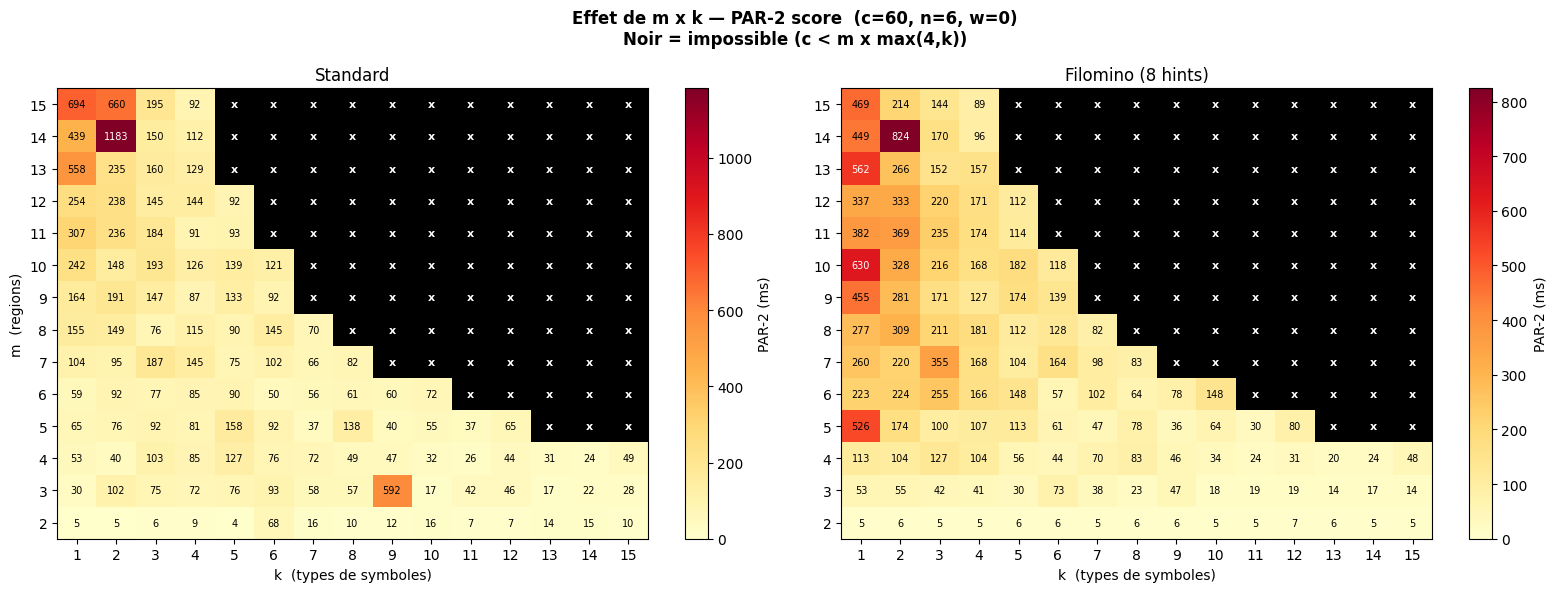

In [14]:
def mk_pivot(csv_path):
    df = pd.read_csv(csv_path)
    df['seconds'] = pd.to_numeric(df['seconds'], errors='coerce')
    df['score'] = df.apply(
        lambda r: r['seconds'] if r['timeout']==0 else 2*TIMEOUT, axis=1
    )
    return (
        df.groupby(['m','k'])['score'].mean()
          .reindex(pd.MultiIndex.from_product([M_VALS, K_VALS], names=['m','k']))
          .unstack('k') * 1000
    )

pivot_std = mk_pivot(CSV_MK_STD)
pivot_fil = mk_pivot(CSV_MK_FIL)

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad('black')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Effet de m x k — PAR-2 score  (c={C_MK}, n=6, w=0)\nNoir = impossible (c < m x max(4,k))',
    fontsize=12, fontweight='bold'
)

for ax, pivot, label in [
    (axes[0], pivot_std, 'Standard'),
    (axes[1], pivot_fil, f'Filomino ({H_MAX} hints)')
]:
    masked = np.ma.masked_invalid(pivot.values)
    vmax = float(masked.max()) if masked.count() > 0 else 1.0
    im = ax.imshow(masked, aspect='auto', cmap=cmap, origin='lower',
                   vmin=0, vmax=vmax)
    ax.set_xticks(range(len(K_VALS)))
    ax.set_xticklabels(K_VALS)
    ax.set_yticks(range(len(M_VALS)))
    ax.set_yticklabels(M_VALS)
    ax.set_xlabel('k  (types de symboles)')
    ax.set_ylabel('m  (regions)' if label == 'Standard' else '')
    ax.set_title(label)
    for i, m in enumerate(M_VALS):
        for j, k in enumerate(K_VALS):
            try:
                val = pivot.loc[m, k]
            except KeyError:
                val = float('nan')
            if np.isnan(val):
                ax.text(j, i, 'x', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
            else:
                color = 'white' if val > vmax * 0.65 else 'black'
                ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                        fontsize=7, color=color)
    plt.colorbar(im, ax=ax, label='PAR-2 (ms)')

fig.tight_layout()
fig.savefig(RESULTS / 'exp_mk.svg', format='svg')
print('Saved', RESULTS / 'exp_mk.svg')
plt.show()

## Expérience 3 — Effet de `w` (nombre de murs)
Fixé : c=80, n=6, m=4, k=3.  
Les murs séparent explicitement les régions → plus de murs = solveur plus rapide (moins d'ambiguïté).

In [15]:
configs_w = [
    (w, 80, 6, 4, 3, w)
    for w in [0, 2, 5, 10, 20, 30, 50]
]
print(f'Exp 3 : {len(configs_w)} configs x {N_RUNS} runs = {len(configs_w)*N_RUNS} instances')
instances_w = generate_instances(configs_w, h=H_MAX, n_runs=N_RUNS)

Exp 3 : 7 configs x 20 runs = 140 instances
  [1/140] gen  0  run=1
  [21/140] gen  2  run=1
  [41/140] gen  5  run=1
  [61/140] gen  10  run=1
  [81/140] gen  20  run=1
  [101/140] gen  30  run=1
  [121/140] gen  50  run=1
  [140/140] gen  50  run=20
  Generated 140/140 instances successfully.


In [16]:
CSV_W_STD = RESULTS / 'exp_w_standard.csv'
print('=== Exp 3 — Standard ===')
solve_variant(instances_w, configs_w, CSV_W_STD, 'w',
              variant='standard', use_hints=False, n_runs=N_RUNS)

=== Exp 3 — Standard ===
  [20/140] standard  w=0
  [40/140] standard  w=2
  [60/140] standard  w=5
  [80/140] standard  w=10
  [100/140] standard  w=20
  [120/140] standard  w=30
  [140/140] standard  w=50
  Done. 4 timeouts / 140 runs.


In [17]:
CSV_W_FIL = RESULTS / 'exp_w_filomino.csv'
print(f'=== Exp 3 — Filomino ({H_MAX} hints) ===')
solve_variant(instances_w, configs_w, CSV_W_FIL, 'w',
              variant='filomino', use_hints=True, h_limit=H_MAX, n_runs=N_RUNS)

=== Exp 3 — Filomino (8 hints) ===
  [20/140] filomino  w=0
  [40/140] filomino  w=2
  [60/140] filomino  w=5
  [80/140] filomino  w=10
  [100/140] filomino  w=20
  [120/140] filomino  w=30
  [140/140] filomino  w=50
  Done. 0 timeouts / 140 runs.


 variant  value     score       std  n_timeouts
standard      0  2.901014  5.860645         0.0
standard      2  7.588648 26.645441         1.0
standard      5 15.673167 36.649316         2.0
standard     10  6.558437 26.720290         1.0
standard     20  0.864351  2.911275         0.0
standard     30  0.012947  0.016588         0.0
standard     50  0.007296  0.000845         0.0
Saved results\exp_w.svg


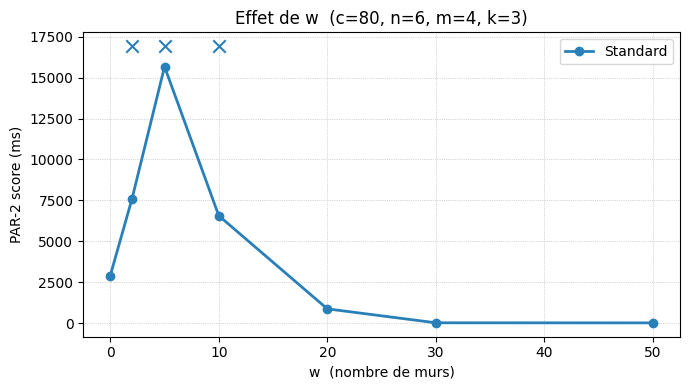

In [19]:
df_w = pd.concat([pd.read_csv(CSV_W_STD)], ignore_index=True)
df_w['seconds'] = pd.to_numeric(df_w['seconds'], errors='coerce')
df_w['score'] = df_w.apply(lambda r: r['seconds'] if r['timeout']==0 else 2*TIMEOUT, axis=1)

agg_w = (df_w.groupby(['variant', 'value'])['score']
          .agg(score='mean', std='std').reset_index().sort_values(['variant', 'value']))
n_to_w = (df_w[df_w['timeout']==1]
           .groupby(['variant','value']).size().reset_index(name='n_timeouts'))
agg_w = agg_w.merge(n_to_w, on=['variant','value'], how='left').fillna({'n_timeouts': 0})

print(agg_w.to_string(index=False))
plot_line(agg_w,
    xlabel='w  (nombre de murs)',
    title='Effet de w  (c=80, n=6, m=4, k=3)',
    out_svg=RESULTS / 'exp_w.svg')

 variant  value     score       std  n_timeouts
filomino      0  2.021205  4.646405         0.0
filomino      2  0.839096  1.239905         0.0
filomino      5  1.915939  3.524291         0.0
filomino     10  0.762599  1.221756         0.0
filomino     20  0.119595  0.294906         0.0
filomino     30  0.011019  0.010419         0.0
filomino     50  0.007118  0.000998         0.0
standard      0  2.901014  5.860645         0.0
standard      2  7.588648 26.645441         1.0
standard      5 15.673167 36.649316         2.0
standard     10  6.558437 26.720290         1.0
standard     20  0.864351  2.911275         0.0
standard     30  0.012947  0.016588         0.0
standard     50  0.007296  0.000845         0.0
Saved results\exp_w.svg


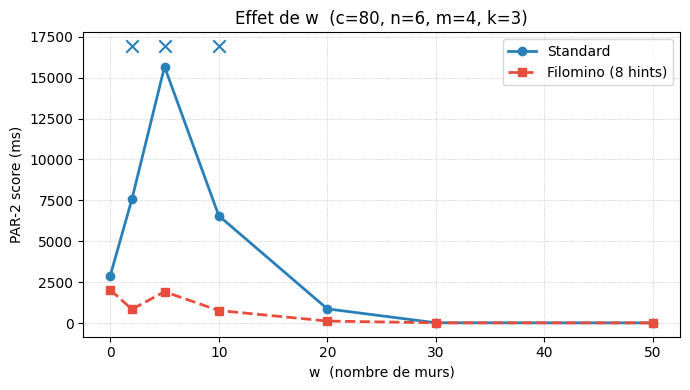

In [18]:
df_w = pd.concat([pd.read_csv(CSV_W_STD), pd.read_csv(CSV_W_FIL)], ignore_index=True)
df_w['seconds'] = pd.to_numeric(df_w['seconds'], errors='coerce')
df_w['score'] = df_w.apply(lambda r: r['seconds'] if r['timeout']==0 else 2*TIMEOUT, axis=1)

agg_w = (df_w.groupby(['variant', 'value'])['score']
          .agg(score='mean', std='std').reset_index().sort_values(['variant', 'value']))
n_to_w = (df_w[df_w['timeout']==1]
           .groupby(['variant','value']).size().reset_index(name='n_timeouts'))
agg_w = agg_w.merge(n_to_w, on=['variant','value'], how='left').fillna({'n_timeouts': 0})

print(agg_w.to_string(index=False))
plot_line(agg_w,
    xlabel='w  (nombre de murs)',
    title='Effet de w  (c=80, n=6, m=4, k=3)',
    out_svg=RESULTS / 'exp_w.svg')

## Expérience 4 — Effet de `h` (nombre d'indices Filomino)
Fixé : c=80, n=6, m=4, k=3, w=10.  
Les instances sont générées **une seule fois** avec H_MAX indices `cell_size_hint`.  
On résout chaque instance successivement avec h=0, 1, 2, …, H_MAX indices fournis au solveur.  
**h=0 est équivalent au solveur Standard** (aucun indice de taille utilisé).

In [ ]:
C4, N4, M4, K4, W4 = 60, 6, 3, 9, 0

configs_h4 = [(H_MAX, C4, N4, M4, K4, W4)]
print(f'Exp 4 : génération de {N_RUNS} instances avec {H_MAX} hints...')
instances_h4 = generate_instances(configs_h4, h=H_MAX, n_runs=N_RUNS)
print(f'Instances pretes pour h=0..{H_MAX}  ({N_RUNS*(H_MAX+1)} runs au total)')

Exp 4 : génération de 20 instances avec 8 hints...
  [1/20] gen  8  run=1
  [20/20] gen  8  run=20
  Generated 20/20 instances successfully.
Instances pretes pour h=0..8  (180 runs au total)


In [30]:
CSV_H = RESULTS / 'exp_h.csv'
init_csv(CSV_H)

H_VALS = list(range(H_MAX + 1))
total = len(H_VALS) * N_RUNS
cur = 0
n_timeouts = 0

for h in H_VALS:
    for run in range(N_RUNS):
        cur += 1
        inst = instances_h4.get((0, run))
        if inst is None:
            append_row(CSV_H, variant='filomino', varied_param='h', value=h,
                       c=C4, n=N4, m=M4, k=K4, w=W4, h=h, run=run+1,
                       seconds=float('inf'))
            n_timeouts += 1
            continue
        solver.facts = list(inst)
        secs = solver.run_solver(use_hints=True, h_limit=h, timeout=TIMEOUT)
        append_row(CSV_H, variant='filomino', varied_param='h', value=h,
                   c=C4, n=N4, m=M4, k=K4, w=W4, h=h, run=run+1, seconds=secs)
        if secs == float('inf'):
            n_timeouts += 1
        if cur % 20 == 0 or cur == total:
            print(f'  [{cur}/{total}]  h={h}  run={run+1}')

print(f'Done. {n_timeouts} timeouts / {total} runs.')

  [20/180]  h=0  run=20
  [40/180]  h=1  run=20
  [60/180]  h=2  run=20
  [80/180]  h=3  run=20
  [100/180]  h=4  run=20
  [120/180]  h=5  run=20
  [140/180]  h=6  run=20
  [160/180]  h=7  run=20
  [180/180]  h=8  run=20
Done. 0 timeouts / 180 runs.


 value    score      std  n_timeouts
     0 0.039366 0.114339         0.0
     1 0.018890 0.041641         0.0
     2 0.020799 0.047912         0.0
     3 0.017511 0.036827         0.0
     4 0.080752 0.319629         0.0
     5 0.021924 0.065569         0.0
     6 0.035161 0.131563         0.0
     7 0.026370 0.089950         0.0
     8 0.019122 0.061298         0.0
Saved results\exp_h.svg


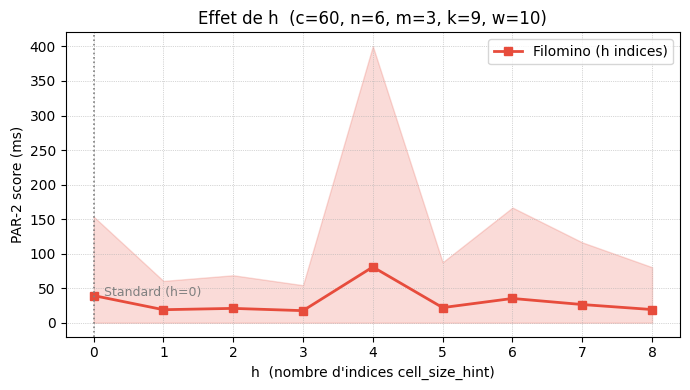

In [31]:
df_h = pd.read_csv(CSV_H)
df_h['seconds'] = pd.to_numeric(df_h['seconds'], errors='coerce')
df_h['score'] = df_h.apply(lambda r: r['seconds'] if r['timeout']==0 else 2*TIMEOUT, axis=1)
agg_h = (df_h.groupby('value')['score']
          .agg(score='mean', std='std').reset_index().sort_values('value'))
n_to_h = df_h[df_h['timeout']==1].groupby('value').size().reset_index(name='n_timeouts')
agg_h = agg_h.merge(n_to_h, on='value', how='left').fillna({'n_timeouts': 0})

print(agg_h.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(agg_h['value'], agg_h['score'] * 1000,
        's-', color='#E74C3C', linewidth=2, label='Filomino (h indices)')
ax.fill_between(
    agg_h['value'],
    (agg_h['score'] - agg_h['std'].fillna(0)).clip(lower=0) * 1000,
    (agg_h['score'] + agg_h['std'].fillna(0)) * 1000,
    alpha=0.2, color='#E74C3C'
)
to_h = agg_h[agg_h['n_timeouts'] > 0]
if not to_h.empty:
    ymax = agg_h['score'].max() * 1000 * 1.06
    ax.scatter(to_h['value'], [ymax] * len(to_h),
               marker='x', s=80, color='red', zorder=5)
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.2)
ax.text(0.15, agg_h['score'].iloc[0] * 1000 * 0.97,
        'Standard (h=0)', color='gray', fontsize=9)
ax.set_xlabel("h  (nombre d'indices cell_size_hint)")
ax.set_ylabel('PAR-2 score (ms)')
ax.set_title(f'Effet de h  (c={C4}, n={N4}, m={M4}, k={K4}, w={W4})')
ax.set_xticks(H_VALS)
ax.legend()
ax.grid(True, linestyle=':', linewidth=0.5)
fig.tight_layout()
fig.savefig(RESULTS / 'exp_h.svg', format='svg')
print('Saved', RESULTS / 'exp_h.svg')
plt.show()

## Résumé — Toutes les expériences
Panneau 4-en-1 : Exp 1 (c), Exp 2 (m×k heatmap Standard), Exp 3 (w), Exp 4 (h).

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('3DSRP — Résumé PAR-2', fontsize=13, fontweight='bold')

# Exp 1 : c
ax = axes[0]
if CSV_C_STD.exists() and CSV_C_FIL.exists():
    df = pd.concat([pd.read_csv(CSV_C_STD), pd.read_csv(CSV_C_FIL)], ignore_index=True)
    df['seconds'] = pd.to_numeric(df['seconds'], errors='coerce')
    df['score'] = df.apply(lambda r: r['seconds'] if r['timeout']==0 else 2*TIMEOUT, axis=1)
    for v, (fmt, col, lbl) in STYLES.items():
        sub = df[df['variant']==v].groupby('value')['score'].mean().reset_index().sort_values('value')
        ax.plot(sub['value'], sub['score']*1000, fmt, color=col, linewidth=1.8, label=lbl)
ax.set_xlabel('c')
ax.set_ylabel('PAR-2 (ms)')
ax.set_title('Effet de c')
ax.legend(fontsize=8)
ax.grid(True, linestyle=':', linewidth=0.5)

# Exp 2 : m×k (Standard heatmap)
ax = axes[1]
if CSV_MK_STD.exists():
    df2 = pd.read_csv(CSV_MK_STD)
    df2['seconds'] = pd.to_numeric(df2['seconds'], errors='coerce')
    df2['score'] = df2.apply(lambda r: r['seconds'] if r['timeout']==0 else 2*TIMEOUT, axis=1)
    pivot2 = df2.groupby(['m','k'])['score'].mean().unstack() * 1000
    masked2 = np.ma.masked_invalid(pivot2.values)
    cmap2 = plt.cm.YlOrRd.copy()
    cmap2.set_bad('black')
    im = ax.imshow(masked2, aspect='auto', cmap=cmap2, origin='lower')
    ax.set_xticks(range(len(pivot2.columns)))
    ax.set_xticklabels(pivot2.columns, fontsize=7)
    ax.set_yticks(range(len(pivot2.index)))
    ax.set_yticklabels(pivot2.index, fontsize=7)
    ax.set_xlabel('k')
    ax.set_ylabel('m')
    ax.set_title('Effet m x k (Standard)')
    plt.colorbar(im, ax=ax, label='PAR-2 ms')

# Exp 3 : w
ax = axes[2]
if CSV_W_STD.exists() and CSV_W_FIL.exists():
    df3 = pd.concat([pd.read_csv(CSV_W_STD), pd.read_csv(CSV_W_FIL)], ignore_index=True)
    df3['seconds'] = pd.to_numeric(df3['seconds'], errors='coerce')
    df3['score'] = df3.apply(lambda r: r['seconds'] if r['timeout']==0 else 2*TIMEOUT, axis=1)
    for v, (fmt, col, lbl) in STYLES.items():
        sub = df3[df3['variant']==v].groupby('value')['score'].mean().reset_index().sort_values('value')
        ax.plot(sub['value'], sub['score']*1000, fmt, color=col, linewidth=1.8)
ax.set_xlabel('w')
ax.set_title('Effet de w')
ax.grid(True, linestyle=':', linewidth=0.5)

# Exp 4 : h
ax = axes[3]
if CSV_H.exists():
    df4 = pd.read_csv(CSV_H)
    df4['seconds'] = pd.to_numeric(df4['seconds'], errors='coerce')
    df4['score'] = df4.apply(lambda r: r['seconds'] if r['timeout']==0 else 2*TIMEOUT, axis=1)
    sub4 = df4.groupby('value')['score'].mean().reset_index().sort_values('value')
    ax.plot(sub4['value'], sub4['score']*1000, 's-', color='#E74C3C', linewidth=1.8)
ax.set_xlabel('h  (indices Filomino)')
ax.set_title('Effet de h')
ax.grid(True, linestyle=':', linewidth=0.5)

fig.tight_layout()
fig.savefig(RESULTS / 'summary.svg', format='svg')
print('Saved', RESULTS / 'summary.svg')
plt.show()